# Import Libraries

In [263]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import scanpy as sc 
import pygenelab as pgl
import decoupler as dc
import pandas as pd

# Util Functions

In [265]:
# calculate cliffs delta

# Get Dataset

In [266]:
# # load complete mice dataset
# MICE_DATASET_PATH = (
#     r"/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/"
#     r"integrated_samples/objects/adata_harmony_celloracle_compatible_v2.h5ad"
# )
# mice_dataset =  sc.read_h5ad(MICE_DATASET_PATH)

# # load female fastiix and fastiib
# mice_dataset_female = mice_dataset[mice_dataset.obs["sex"] == "F"].copy()
# mice_dataset_female_iix_iib = mice_dataset_female[(mice_dataset_female.obs["C_scANVI"] == "Fast IIX") | 
#                                                   (mice_dataset_female.obs["C_scANVI"] == "Fast IIB")].copy()

In [267]:
# female metacells

# load female metacell dataset
FEMALE_METACELL_PATH = r"/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/seacells_F_FastIIB_FastIIX_harmonyv2.h5ad" 
female_metacell_dataset = sc.read_h5ad(FEMALE_METACELL_PATH)

# create condition column
female_metacell_dataset.obs["condition"] = (
    female_metacell_dataset.obs["y"]
    .apply(lambda x: "WT" if x == 0 else "KO")
).copy()

In [268]:
# specify which dataset to use
adata = female_metacell_dataset.copy()

In [269]:
display(adata.obs.head())

,y,sample_id,condition
SEACell,,,
0_F15_WT,0,F15,WT
0_F3_WT,0,F3,WT
0_F4_WT,0,F4,WT
0_F706_KO,1,F706,KO
0_F785_KO,1,F785,KO


# Get Geneset

In [270]:
# atrophy pathway

# ["UBB","UBC","FBXO32","TRIM63","MDM2","FBXO30","CAMK2B","TIE1","PSMA1","PSMA2","PSMA3","PSMA4","PSMA5","PSMA6","PSMA7","PSMB1","PSMB2","PSMB3","PSMB4","FBXO21","FBXO31","NEDD4","UBE2B","UBE2G1","UBE2J1","CTSL","CTSV","BNIP3","DEPP1","GABARAPL1","MAP1LC3","RETREG1","SQSTM1","CAPN1","CAPN2","ATF4","FOXO1","FOXO3A","HDAC9","RUNX1","AMPD3","CHRNA1","CDKN1A"]

In [ ]:
# metabolic pathway

# marked metabolic pathways

# HALLMARK_FATTY_ACID_METABOLISM
# HALLMARK_XENOBIOTIC_METABOLISM
# REACTOME_PYRUVATE_METABOLISM
# REACTOME_PHOSPHOLIPID_METABOLISM
# REACTOME_GLYCOGEN_METABOLISM
# REACTOME_GLYCOSAMINOGLYCAN_METABOLISM
# WP_PURINE_METABOLISM

# mice all pathways path
MICE_ALL_PATHWAYS = "/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/msigdb.v2024.1.Mm.symbols.gmt"

# specify pathway
pathway = "WP_PURINE_METABOLISM"

# load pathway genes
metabolic_pathway_genes = pgl.convert_gmt_to_decoupler_format(MICE_ALL_PATHWAYS, include_pathways=[pathway], gene_origin="mice")

In [272]:
# atrophy pathway

custom_atrophy_genes = [
    "UBB", "UBC", "FBXO32", "TRIM63", "MDM2", "FBXO30", "CAMK2B", "TIE1",
    "PSMA1", "PSMA2", "PSMA3", "PSMA4", "PSMA5", "PSMA6", "PSMA7",
    "PSMB1", "PSMB2", "PSMB3", "PSMB4", "FBXO21", "FBXO31", "NEDD4",
    "UBE2B", "UBE2G1", "UBE2J1", "CTSL", "CTSV", "BNIP3", "DEPP1",
    "GABARAPL1", "MAP1LC3", "RETREG1", "SQSTM1", "CAPN1", "CAPN2",
    "ATF4", "FOXO1", "FOXO3A", "HDAC9", "RUNX1", "AMPD3", "CHRNA1",
    "CDKN1A"
]

pathway = "Atrophy_Pathway_(PMID: 31325479)"

# convert human-style uppercase symbols to mouse-style title case
custom_atrophy_genes_mouse = [gene.capitalize() for gene in custom_atrophy_genes]

# create decoupler input dataframe
atrophy_pathway_genes = pd.DataFrame({
    "source": pathway,
    "target": custom_atrophy_genes_mouse
})

In [273]:
# specify which pathway to use


pathway_genes = atrophy_pathway_genes
display(pathway_genes.head())
print(f"Number Of Genes: {len(pathway_genes)}")

,source,target
0,Atrophy_Pathway_(PMID: 31325479),Ubb
1,Atrophy_Pathway_(PMID: 31325479),Ubc
2,Atrophy_Pathway_(PMID: 31325479),Fbxo32
3,Atrophy_Pathway_(PMID: 31325479),Trim63
4,Atrophy_Pathway_(PMID: 31325479),Mdm2


Number Of Genes: 43


# Get Scores

In [274]:
# check if genes are in adata
pgl.check_genes_in_adata(pathway_genes, adata)

{'total_genes_checked': 43,
 'genes_found_in_adata': 6,
 'genes_missing_from_adata': 37,
 'matched_genes': ['Fbxo32', 'Trim63', 'Retreg1', 'Hdac9', 'Runx1', 'Chrna1'],
 'missing_genes': ['Ubb',
  'Ubc',
  'Mdm2',
  'Fbxo30',
  'Camk2b',
  'Tie1',
  'Psma1',
  'Psma2',
  'Psma3',
  'Psma4',
  'Psma5',
  'Psma6',
  'Psma7',
  'Psmb1',
  'Psmb2',
  'Psmb3',
  'Psmb4',
  'Fbxo21',
  'Fbxo31',
  'Nedd4',
  'Ube2b',
  'Ube2g1',
  'Ube2j1',
  'Ctsl',
  'Ctsv',
  'Bnip3',
  'Depp1',
  'Gabarapl1',
  'Map1lc3',
  'Sqstm1',
  'Capn1',
  'Capn2',
  'Atf4',
  'Foxo1',
  'Foxo3a',
  'Ampd3',
  'Cdkn1a']}

In [275]:
%%time

# get scores for om6
decoupler.mt.aucell(
    adata,
    pathway_genes,
    raw=False,
    verbose=True
)

2026-05-11 23:15:31 | [INFO] aucell - Running aucell
2026-05-11 23:15:31 | [INFO] Extracted omics mat with 451 rows (observations) and 3000 columns (features)
2026-05-11 23:15:31 | [WARNING] 16 features of mat are empty, they will be removed
2026-05-11 23:15:31 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-05-11 23:15:31 | [INFO] Network has 6 unique features and 1 unique sources
2026-05-11 23:15:31 | [INFO] aucell - calculating 1 AUCs for 2984 targets across 451 observations, categorizing features at rank=150
100%|██████████| 451/451 [00:00<00:00, 3663.62it/s]
2026-05-11 23:15:32 | [INFO] aucell - done


CPU times: user 7.72 s, sys: 39.4 ms, total: 7.76 s
Wall time: 143 ms


In [276]:
adata.obs[pathway] = adata.obsm["score_aucell"][pathway].copy()
display(adata.obs[pathway].head(10))

SEACell
0_F15_WT      0.058020
0_F3_WT       0.312856
0_F4_WT       0.407281
0_F706_KO     0.334471
0_F785_KO     0.220705
0_F7_KO       0.235495
100_F15_WT    0.093288
100_F7_KO     0.213879
101_F15_WT    0.211604
101_F7_KO     0.171786
Name: Atrophy_Pathway_(PMID: 31325479), dtype: float64

In [277]:
# get scores per group 
group_score_df = pgl.prepare_group_score_df(adata, group_col="condition", value_col=pathway, dropna=True)
display(group_score_df.head())

,condition,Atrophy_Pathway_(PMID: 31325479)
0,WT,0.058020
1,WT,0.312856
2,WT,0.407281
3,KO,0.334471
4,KO,0.220705


In [278]:
pgl.summarize_score_by_group(group_score_df, group_col="condition", score_col=pathway)

,condition,count,mean,median,std,min,max
0,KO,219,0.263214,0.265074,0.051979,0.124005,0.389078
1,WT,232,0.235706,0.251422,0.098385,0.000000,0.447099


# Plot

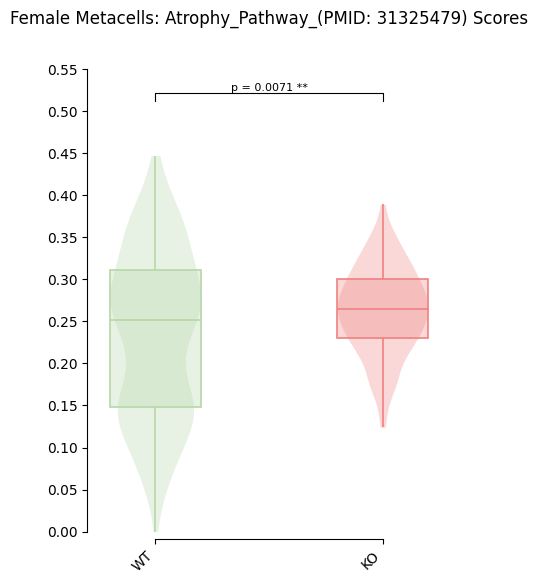

<Figure size 640x480 with 0 Axes>

In [279]:
# choose order
sample_order = ["WT", "KO"]

# palette keys must match age_label values
palette = {
    "WT": "#B6D7A8",
    "KO": "#F08080"
}

# plot violin box plot
fig_violin_box = pgl.plot_violin_box_combo(group_score_df,
                                           x_var="condition",
                                           y_var=pathway,
                                           title=f"Female Metacells: {pathway} Scores",
                                           palette=palette,
                                           x_ticks=sample_order,
                                           show_scatter=False)

display(fig_violin_box)

In [280]:
# subset wt and get gene correlation
adata_wt = pgl.subset_adata_by_obs(adata, filters={"condition": "WT"})
ranked_genes_wt = pgl.compute_gene_correlation_against_score(adata_wt, 
                                                              pgl.get_pathway_genes(pathway_genes, pathway), 
                                                              score=pathway)
display(ranked_genes_wt.head())

# subset ko and get gene correlation
adata_ko = pgl.subset_adata_by_obs(adata, filters={"condition": "KO"})
ranked_genes_ko = pgl.compute_gene_correlation_against_score(adata_ko, 
                                                              pgl.get_pathway_genes(pathway_genes, pathway), 
                                                              score=pathway)
display(ranked_genes_ko.head())

,gene,spearman_corr,rank
0,Fbxo32,0.793968,1
1,Retreg1,0.672891,2
2,Trim63,0.651236,3
3,Runx1,0.322034,4
4,Hdac9,0.186970,5


,gene,spearman_corr,rank
0,Fbxo32,0.502374,1
1,Trim63,0.483114,2
2,Retreg1,0.351503,3
3,Hdac9,0.062273,4
4,Runx1,-0.070412,5


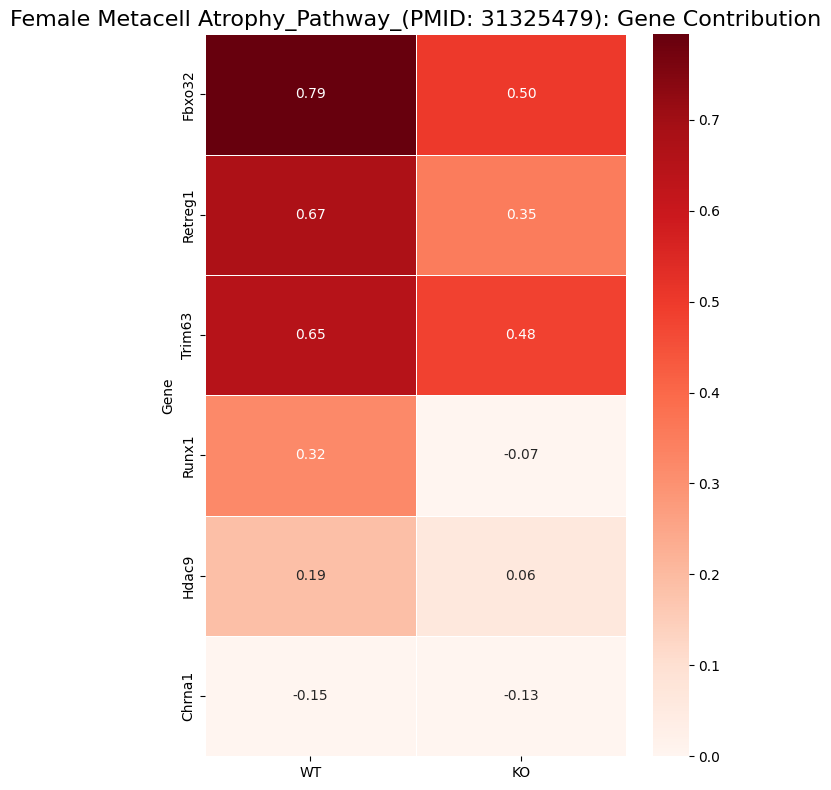

In [281]:
gene_contribution_df, fig_gene_contribution_heatmap, ax_gene_contribution = pgl.plot_gene_contribution_heatmap(
    {"WT": ranked_genes_wt,
     "KO": ranked_genes_ko},
     title=f"Female Metacell {pathway}: Gene Contribution"
)

# Save Image

In [282]:
# save image

from pathlib import Path

# figures to save
figures_to_save = {
    "Violin_Box": fig_violin_box,
    "Gene_Contribution_Heatmap": fig_gene_contribution_heatmap
}

# output folder
output_dir = Path("Output")
output_dir.mkdir(parents=True, exist_ok=True)


# save each figure as svg and png
for plot_type, fig in figures_to_save.items():

    # create output paths
    svg_path = output_dir / f"F_Metacell_{pathway}_{plot_type}_SVG.svg"
    png_path = output_dir / f"F_Metacell_{pathway}_{plot_type}_PNG.png"

    # save editable svg
    pgl.save_editable_svg(
        fig=fig,
        output_path=svg_path
    )

    # save png
    pgl.save_fig_as_png(
        fig=fig,
        output_path=png_path
    )

    print(f"saved: {svg_path}")
    print(f"saved: {png_path}")

saved: Output/F_Metacell_Atrophy_Pathway_(PMID: 31325479)_Violin_Box_SVG.svg
saved: Output/F_Metacell_Atrophy_Pathway_(PMID: 31325479)_Violin_Box_PNG.png
saved: Output/F_Metacell_Atrophy_Pathway_(PMID: 31325479)_Gene_Contribution_Heatmap_SVG.svg
saved: Output/F_Metacell_Atrophy_Pathway_(PMID: 31325479)_Gene_Contribution_Heatmap_PNG.png
